In [63]:
#Machine Learning
#This project aims to compare different Machine Learning algorithms using a customer retail dataset.
#The models used are Logistic Regression,Decision Tree Classifier, and K-Nearest Neighbors(KNN).
#Evaluated the performance process data using accuracy score and confusion matrix.

#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import accuracy_score, confusion_matrix

#Import/Load Dataset
df = pd.read_csv('dataset.csv') # Data source from Kaggle 
#path = kagglehub.dataset_download("sowndarya23/online-retail-dataset")

In [41]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 8:26,3.39,17850.0,United Kingdom


In [64]:
print(df.columns) #Check Dataset

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [65]:
df.describe() #Check Dataset

,Quantity,UnitPrice,CustomerID
count,542014.000000,542014.000000,406934.000000
mean,9.555285,4.611339,15287.724582
std,218.060485,96.750980,1713.702628
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [60]:
df.isnull().sum() #Checking Missing Values

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [61]:
df.fillna(0, inplace=True) #Fill Missing Values

In [76]:
#Encode Country Column
le = LabelEncoder()
df["Country"] = le.fit_transform(df["Country"])
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Purchased
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 8:26,2.55,17850.0,36,0
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 8:26,3.39,17850.0,36,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 8:26,2.75,17850.0,36,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 8:26,3.39,17850.0,36,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 8:26,3.39,17850.0,36,0


In [66]:
#Create Target Variable
df["Purchased"] = (df["Quantity"] > 10).astype(int)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Purchased
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 8:26,2.55,17850.0,United Kingdom,0
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 8:26,3.39,17850.0,United Kingdom,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 8:26,2.75,17850.0,United Kingdom,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 8:26,3.39,17850.0,United Kingdom,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 8:26,3.39,17850.0,United Kingdom,0


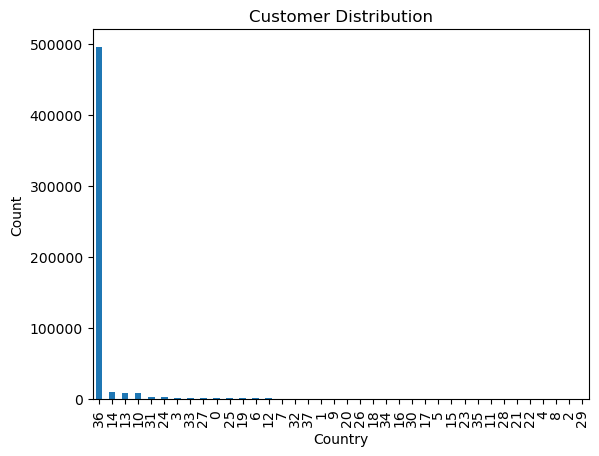

In [77]:
#Visualization
df["Country"].value_counts().plot(kind="bar")

plt.title("Customer Distribution")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

In [78]:
#Freature Selection
X = df[["Quantity", "UnitPrice", "Country"]]
y = df["Purchased"]

In [79]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.2, random_state = 42 )
                                                     

In [80]:
#Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)
print("Logistic Regression Accuracy: ", lr_acc)
print(confusion_matrix(y_test, lr_pred))

Logistic Regression Accuracy:  1.0
[[81837     0]
 [    0 26566]]


In [81]:
#Decision tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
print("Decision Tree Accuracy: ", dt_acc)
print(confusion_matrix(y_test, dt_pred))

Decision Tree Accuracy:  1.0
[[81837     0]
 [    0 26566]]


In [82]:
#KNN
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy :", knn_acc)
print(confusion_matrix(y_test,knn_pred))

KNN Accuracy : 1.0
[[81837     0]
 [    0 26566]]


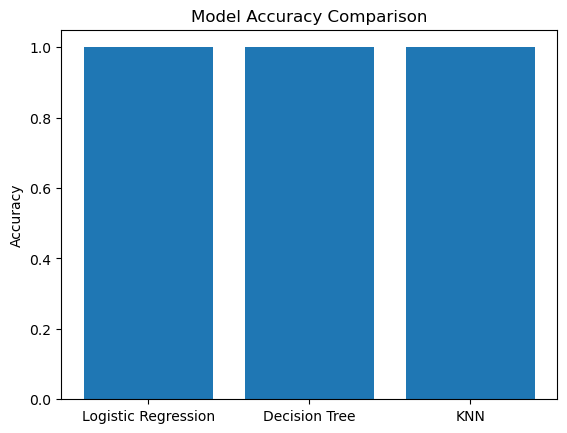

In [84]:
#Accuracy Comparison Graph
models = [
    "Logistic Regression",
    "Decision Tree",
    "KNN"]

accuracies = [ 
    lr_acc,
    dt_acc,
    knn_acc]
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()
    

Conclusion

This Project Compared Logistic Regression, Decision Tree, and KNN using a customer retail dataset.

After Pre-Processing and visualization, all models were trained and evaluated using Accuracy Score and Confusion Matrix

The model with the highest accuracy performed best for this dataset.

This project demonstrates the complete Machine Learning workflow from data Pre-Processing to model evaluation and camparsion.